# Phase 2 — Model, Training, and Explainability
*Review 3 — Heart Sound Classification with XAI*

**Pipeline**
1. Environment setup (Drive mount / local path detection)
2. Data loading (uses Phase 1 outputs: `metadata.csv`, spectrograms, `split_indices.json`)
3. Model: ResNet50 + Squeeze-and-Excitation + Multi-Head Self-Attention
4. Two-phase training (frozen backbone → full fine-tune)
5. Test-set evaluation (accuracy, F1, AUC-ROC, AUC-PR, confusion matrix)
6. Explainability: Grad-CAM, attention maps, SHAP

**Run order**
- Run cells top-to-bottom in Colab (T4/L4) or locally with a CUDA GPU.
- Phase 1 must have been executed at least once so that `metadata.csv` and the cached `.npy` spectrograms exist.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0 — Mount Drive (Colab only) and install dependencies

In [2]:
# Colab: mount Drive. Skip silently on local.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not on Colab — skipping Drive mount.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Install missing dependencies. Safe to re-run.
%pip install -q torch torchvision tqdm scikit-learn matplotlib seaborn pandas shap

## 1 — Imports and path detection

In [4]:
import sys
from pathlib import Path

# Make Review 3 modules importable when running from inside Colab / Jupyter
HERE = Path.cwd()
candidates = [
    HERE,
    HERE / 'Review 3',
    Path('/content/drive/MyDrive/CSE/College/RMS/Review 3'),
]
for c in candidates:
    if (c / 'config.py').exists():
        sys.path.insert(0, str(c))
        print(f'Loading modules from: {c}')
        break

from config   import (
    Paths, AudioConfig, ModelConfig, TrainConfig,
    CLASS_NAMES, get_device, set_seed, is_colab, is_drive_mounted,
)
from data     import load_metadata, load_class_weights, get_dataloaders, HeartSoundDataset
from model    import build_model
from train    import train, plot_training_history
from evaluate import (
    evaluate_on_test, plot_confusion_matrix, plot_roc_pr_curves, save_predictions_csv,
    compute_and_save_extended_metrics,
)
from xai      import (
    visualise_gradcam, visualise_attention, compute_shap_values,
    frequency_share, plot_shap_frequency_importance, plot_shap_sample_overlays,
)
from utils    import build_comparison_table, pick_explainable_indices, metrics_to_dict

Loading modules from: /content/drive/MyDrive/CSE/College/RMS/Review 3


In [5]:
# Path detection — change ``BASE_OVERRIDE`` if your Drive folder differs.
BASE_OVERRIDE = None  # e.g. '/content/drive/MyDrive/CSE/College/RMS'

paths     = Paths.auto_detect(base_override=BASE_OVERRIDE)
audio_cfg = AudioConfig()
model_cfg = ModelConfig()
train_cfg = TrainConfig()

paths.ensure_output_dirs()
set_seed(train_cfg.seed)
device = get_device()

print(f'Colab: {is_colab()}  |  Drive mounted: {is_drive_mounted()}  |  Device: {device}')
print(paths)

Colab: True  |  Drive mounted: True  |  Device: cuda
Paths:
  base_dir           = /content/drive/MyDrive/CSE/College/RMS
  data_dir           = /content/drive/MyDrive/CSE/College/RMS/physionet_2016  [OK]
  raw_dir            = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/raw  [OK]
  spec_dir           = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/spectrograms  [OK]
  metadata_csv       = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/metadata.csv  [OK]
  split_indices_json = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/split_indices.json  [OK]
  class_weights_pt   = /content/drive/MyDrive/CSE/College/RMS/physionet_2016/class_weights.pt  [OK]
  output_dir         = /content/drive/MyDrive/CSE/College/RMS/Review 3/output  [OK]
  checkpoint_dir     = /content/drive/MyDrive/CSE/College/RMS/Review 3/output/checkpoints  [OK]


## 2 — Load data and inspect splits

In [6]:
df = load_metadata(paths)
print(f'Total recordings: {len(df)}')
print('Class distribution:', df['label'].value_counts().sort_index().to_dict())

train_loader, val_loader, test_loader, train_df, val_df, test_df = (
    get_dataloaders(paths, model_cfg, train_cfg, df)
)

class_weights = load_class_weights(paths, train_df, device=device)
print('Class weights:', class_weights.cpu().numpy())

Total recordings: 3541
Class distribution: {0: 2725, 1: 816}
  Loaded splits from split_indices.json
  Train: 2478 | Val:  531 | Test:  532
  Train class dist: {'Normal': 1907, 'Abnormal': 571}
  Val   class dist: {'Normal': 409, 'Abnormal': 122}
  Test  class dist: {'Normal': 409, 'Abnormal': 123}
Class weights: [0.23044337 0.76955664]


In [7]:
# Sanity-check a single batch
X_batch, y_batch = next(iter(train_loader))
print('Batch tensor shape :', tuple(X_batch.shape))
print('Value range        :', f'[{X_batch.min():.3f}, {X_batch.max():.3f}]')
print('First 8 labels     :', y_batch[:8].tolist())

Batch tensor shape : (32, 3, 224, 224)
Value range        : [-2.118, 2.637]
First 8 labels     : [1, 0, 0, 0, 0, 1, 1, 0]


## 3 — Build the model

In [8]:
model = build_model(model_cfg, device=device, pretrained=True, freeze_backbone=True)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


  Backbone frozen: True
  Trainable params: 18,363,906 / Total: 41,871,938


## 4 — Train

Set `NUM_EPOCHS` low for a smoke test, or keep the default 40 epochs for the full run.

In [9]:
import torch

ckpt_path = paths.checkpoint_dir / 'best_model.pth'

# Set SKIP_TRAIN = True to reuse existing checkpoint (fast evaluation/XAI)
# Set SKIP_TRAIN = False to retrain from scratch
SKIP_TRAIN = True

if SKIP_TRAIN and ckpt_path.exists():
    print(f'Found existing checkpoint: {ckpt_path}')
    print('Skipping training. Loading trained model weights...')
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    model.unfreeze_backbone()
    print('Checkpoint loaded successfully! Proceed directly to evaluation.')
else:
    if SKIP_TRAIN:
        print(f'Checkpoint not found at {ckpt_path}. Falling back to training...')
    else:
        print('SKIP_TRAIN is False. Starting training from scratch...')
    history = train(model, train_loader, val_loader, class_weights,
                    paths, train_cfg, device)
    plot_training_history(history, save_path=paths.output_dir / 'training_history.png')


Found existing checkpoint: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/checkpoints/best_model.pth
Skipping training. Loading trained model weights...
Checkpoint loaded successfully! Proceed directly to evaluation.


## 5 — Evaluate on the held-out test set

  Test:   0%|          | 0/17 [00:00<?, ?it/s]


  Test set (532 samples) — 2 classes
  Accuracy          : 0.9079
  Balanced accuracy : 0.8861
  Macro precision   : 0.8642
  Macro recall      : 0.8861
  Macro F1          : 0.8743
  AUC-ROC           : 0.9457
  AUC-PR            : 0.8633
              precision    recall  f1-score   support

      Normal     0.9523    0.9267    0.9393       409
    Abnormal     0.7761    0.8455    0.8093       123

    accuracy                         0.9079       532
   macro avg     0.8642    0.8861    0.8743       532
weighted avg     0.9115    0.9079    0.9092       532



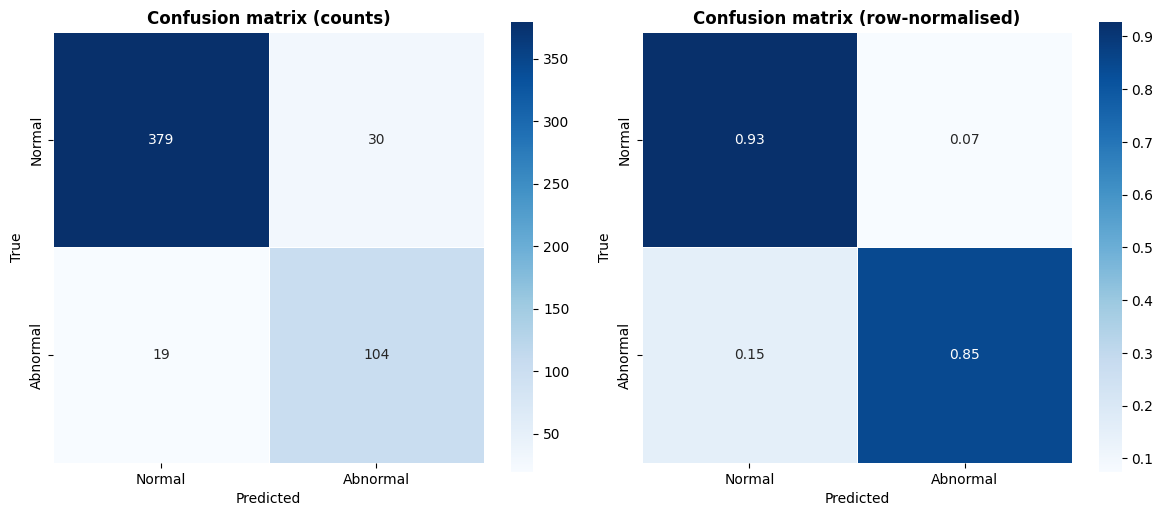

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/confusion_matrix.png


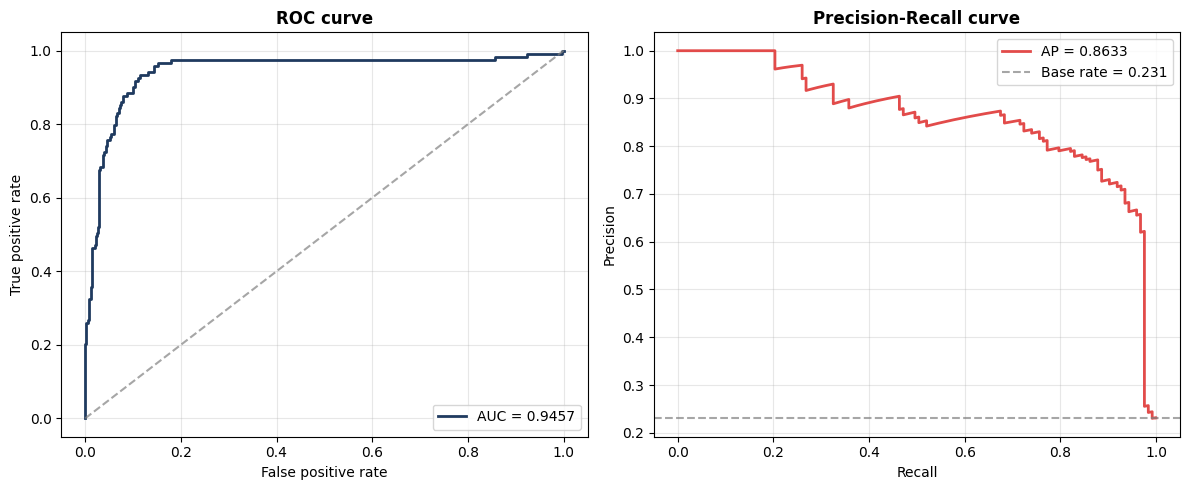

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/roc_pr_curves.png
  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/test_predictions.csv
Test metrics saved.
  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/per_subset_metrics.csv
  Duplicated in train: 70 (acc: 97.14%)
  Unique test rows: 462 (acc: 89.83%)
  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/test_metrics_ci.json


{'per_subset': [{'subset': 'training-a',
   'N': 62,
   'normal': 17,
   'abnormal': 45,
   'accuracy': 79.03,
   'normal_accuracy': 70.59,
   'abnormal_accuracy': 82.22},
  {'subset': 'training-b',
   'N': 54,
   'normal': 42,
   'abnormal': 12,
   'accuracy': 79.63,
   'normal_accuracy': 80.95,
   'abnormal_accuracy': 75.0},
  {'subset': 'training-c',
   'N': 3,
   'normal': 1,
   'abnormal': 2,
   'accuracy': 66.67,
   'normal_accuracy': 100.0,
   'abnormal_accuracy': 50.0},
  {'subset': 'training-d',
   'N': 11,
   'normal': 6,
   'abnormal': 5,
   'accuracy': 45.45,
   'normal_accuracy': 33.33,
   'abnormal_accuracy': 60.0},
  {'subset': 'training-e',
   'N': 338,
   'normal': 306,
   'abnormal': 32,
   'accuracy': 99.11,
   'normal_accuracy': 99.35,
   'abnormal_accuracy': 96.88},
  {'subset': 'training-f',
   'N': 20,
   'normal': 15,
   'abnormal': 5,
   'accuracy': 50.0,
   'normal_accuracy': 53.33,
   'abnormal_accuracy': 40.0},
  {'subset': 'validation',
   'N': 44,
   'norm

In [10]:
import json

metrics = evaluate_on_test(model, test_loader, device, CLASS_NAMES)

plot_confusion_matrix(metrics, CLASS_NAMES,
                      save_path=paths.output_dir / 'confusion_matrix.png')
plot_roc_pr_curves(metrics, CLASS_NAMES,
                   save_path=paths.output_dir / 'roc_pr_curves.png')
save_predictions_csv(metrics, test_df, CLASS_NAMES,
                     save_path=paths.output_dir / 'test_predictions.csv')

with open(paths.output_dir / 'test_metrics.json', 'w') as f:
    json.dump(metrics_to_dict(metrics), f, indent=2)
print('Test metrics saved.')

# Extended metrics: per-subset CSV, bootstrap 95% CIs, duplicate leakage breakdown
compute_and_save_extended_metrics(metrics, test_df, train_df, paths.output_dir)


## 6 — Explainability

Grad-CAM + multi-head attention + SHAP, all overlaid on the original log-mel spectrogram so that time × frequency is directly readable.

In [11]:
test_dataset = HeartSoundDataset(test_df, paths, model_cfg, augment=False)
picks = pick_explainable_indices(metrics, n_correct=2, n_wrong=2,
                                 rng_seed=train_cfg.seed)
print('XAI sample indices:', picks)

XAI sample indices: [310, 41, 19, 349]


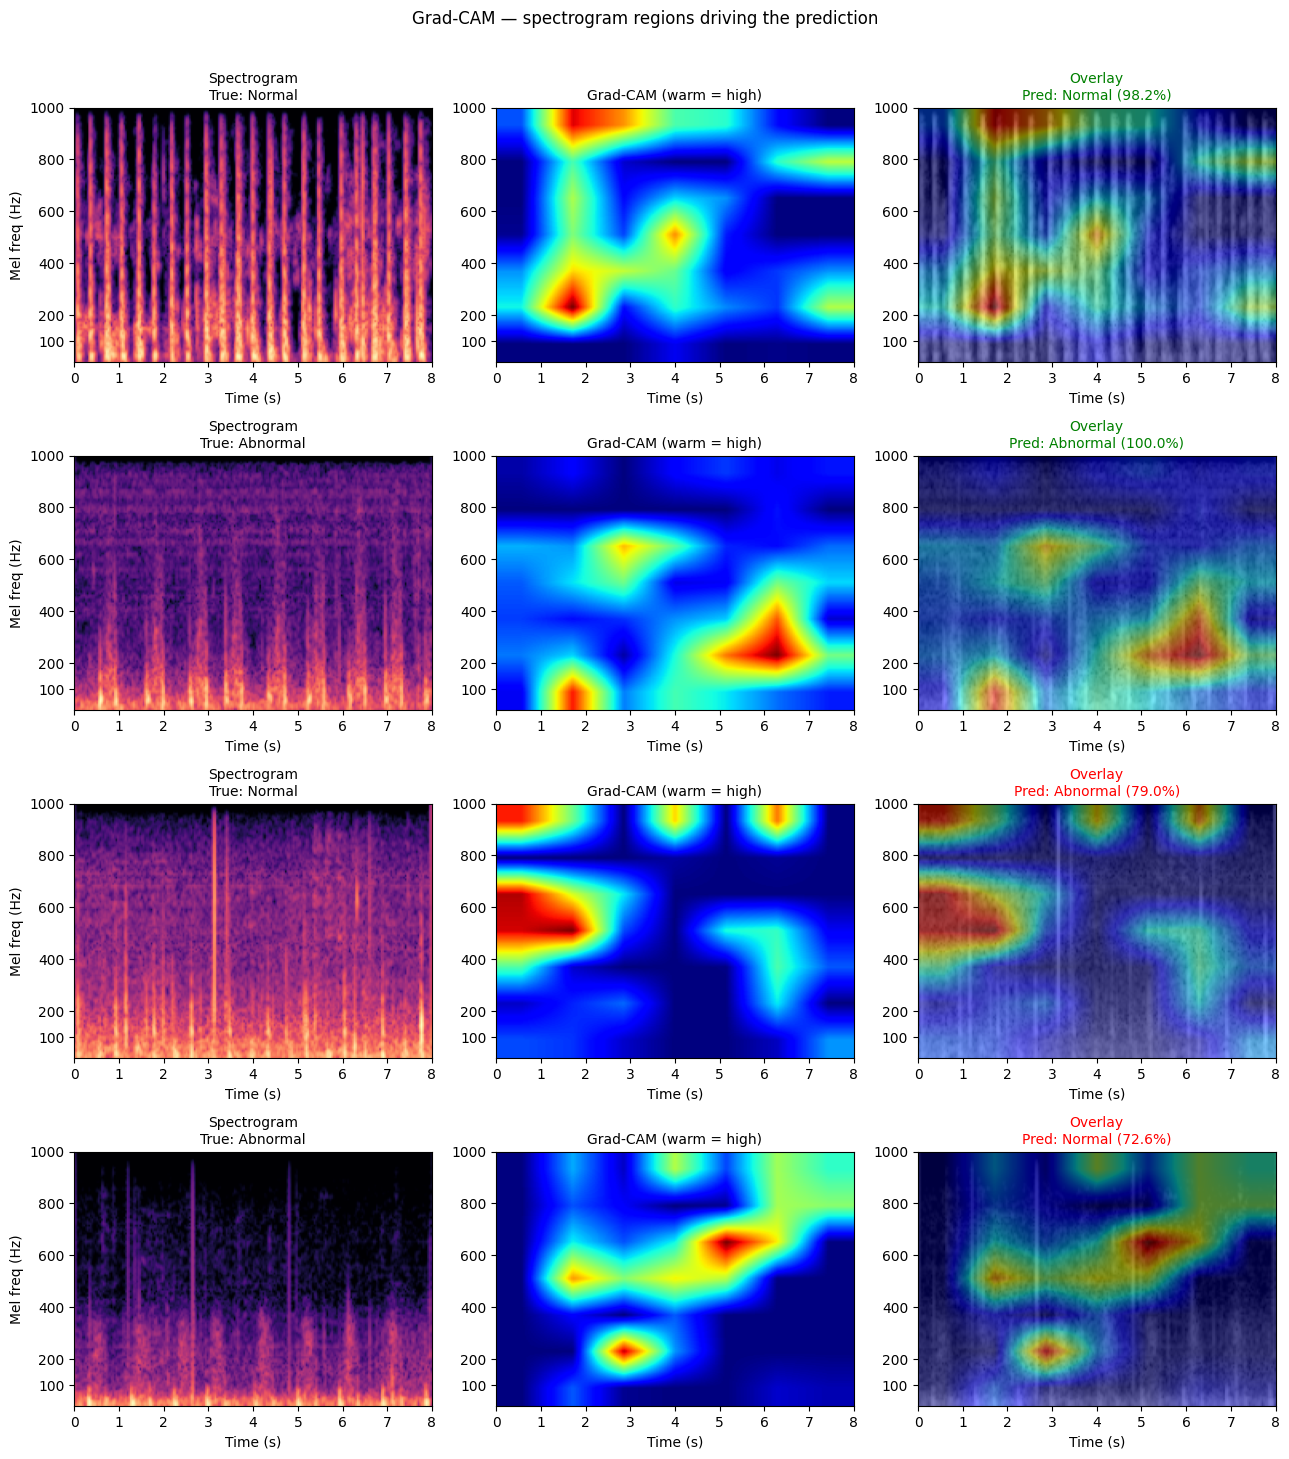

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/gradcam_overlays.png


In [12]:
# Grad-CAM — final ResNet50 conv layer
visualise_gradcam(model, test_dataset, picks, device, audio_cfg, CLASS_NAMES,
                  save_path=paths.output_dir / 'gradcam_overlays.png')

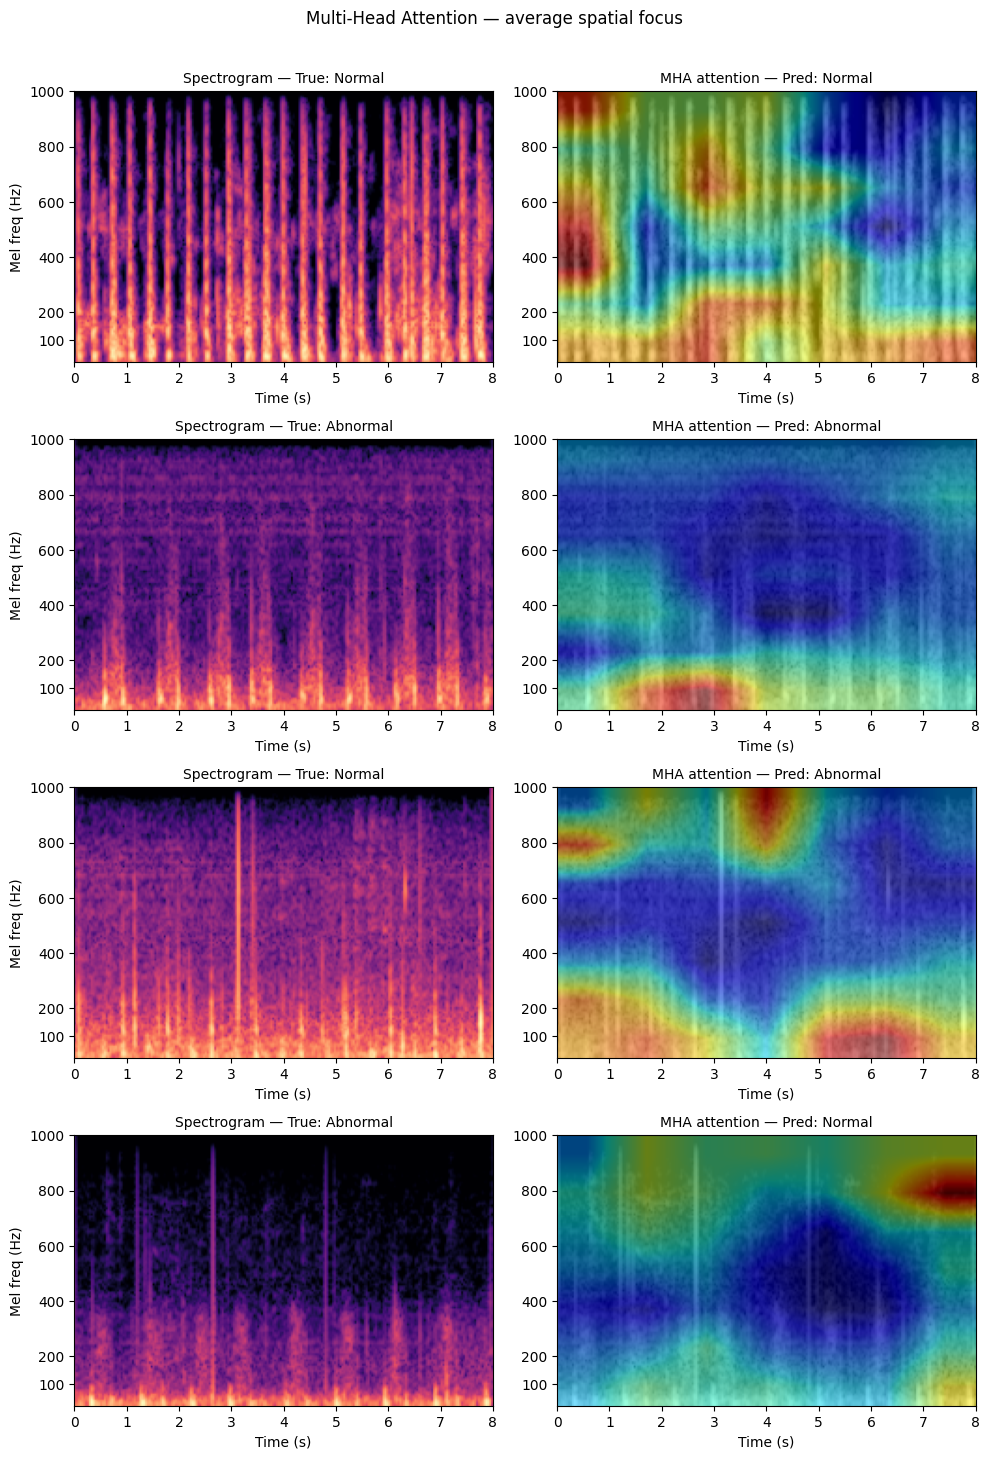

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/attention_overlays.png


In [13]:
# Multi-Head Attention — average over heads + queries
visualise_attention(model, test_dataset, picks, device, audio_cfg, CLASS_NAMES,
                    save_path=paths.output_dir / 'attention_overlays.png')

Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/shap_values.npz

  SHAP Frequency Attribution Summary
  Cutoff frequency: 400 Hz
  Axis share below cutoff: 0.3884 (38.84%)
  class_0 share below cutoff: 0.4257 (42.57%)
  class_1 share below cutoff: 0.4287 (42.87%)
  Mean attribution share below cutoff: 0.4272 (42.72%)
SHAP frequency share summary (< 400 Hz):
  Normal below 400 Hz   : 42.57%
  Abnormal below 400 Hz : 42.87%
  Overall below 400 Hz  : 42.72%
  Axis below 400 Hz     : 38.84%


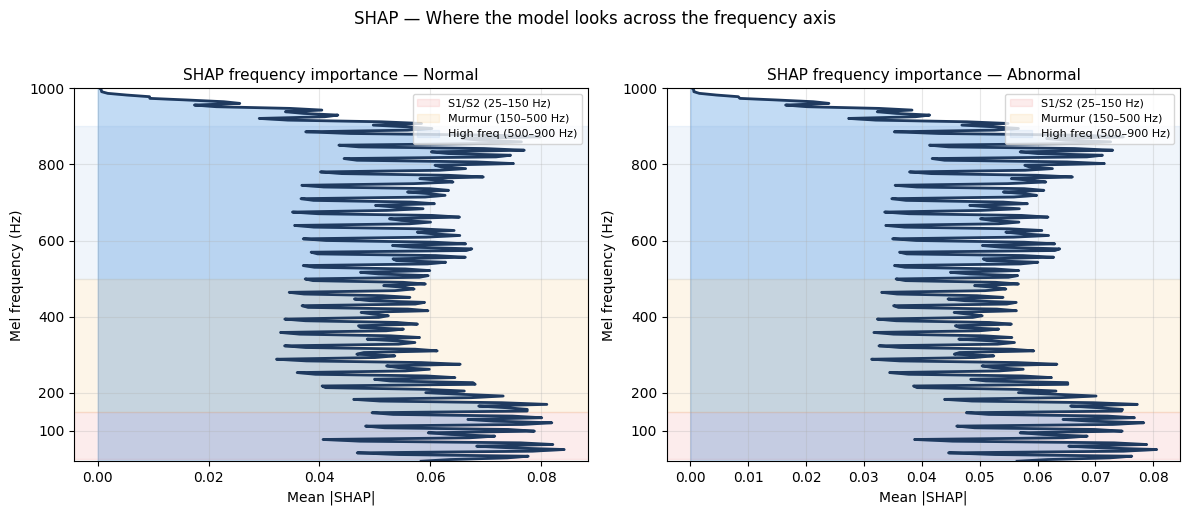

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/shap_frequency_importance.png


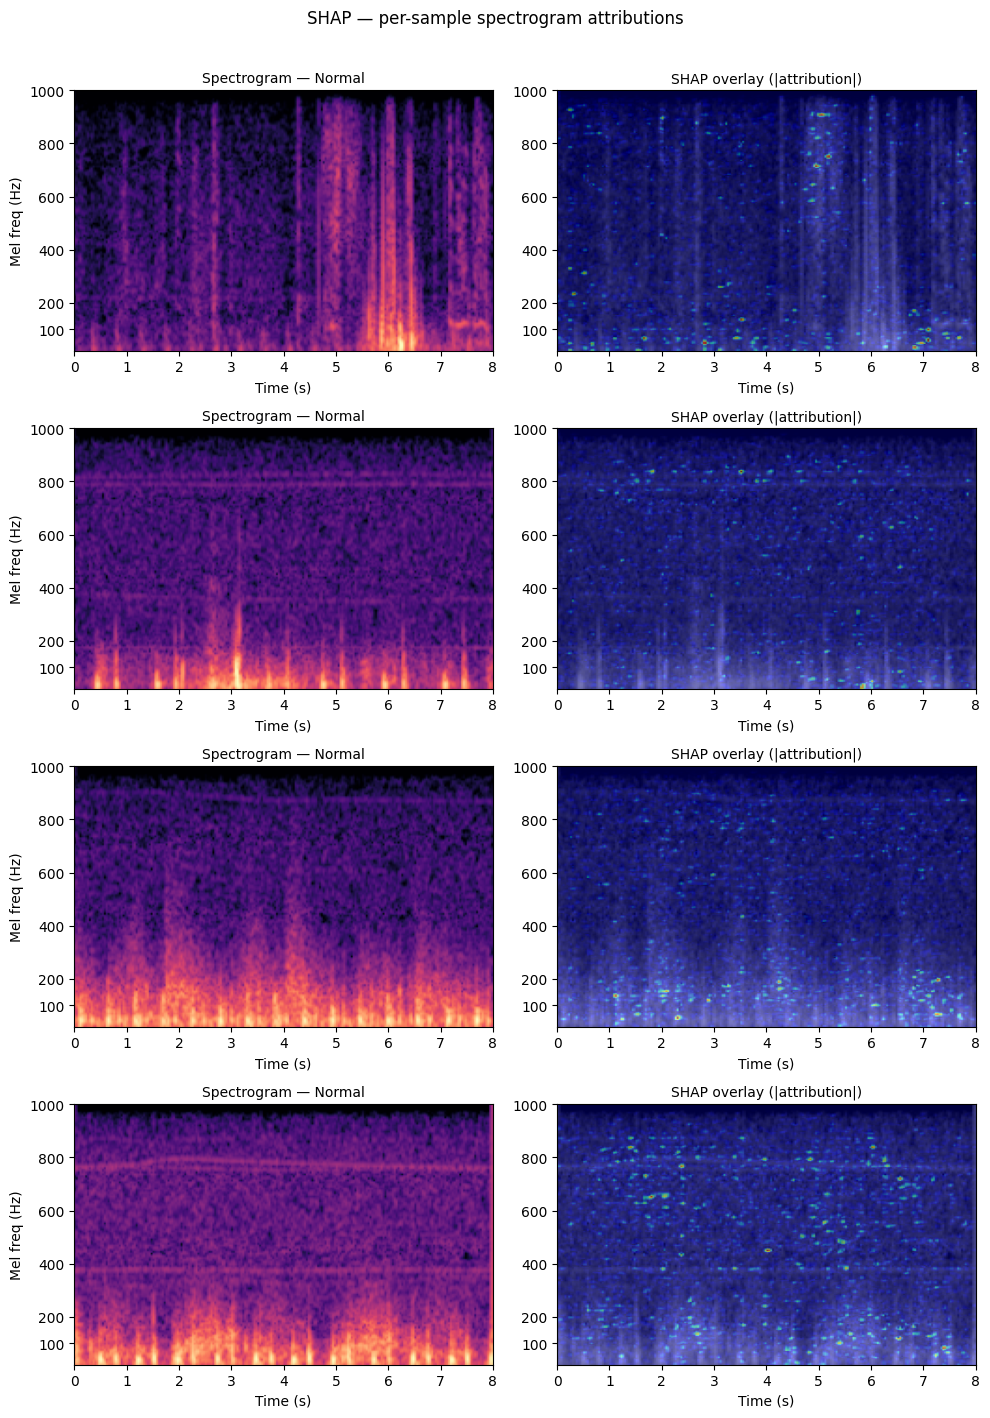

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/shap_sample_overlays.png


In [17]:
import numpy as np
import json

# SHAP — GradientExplainer (balanced 32 samples: 16 Normal, 16 Abnormal)
shap_values, shap_inputs, shap_labels, shap_indices = compute_shap_values(
    model, train_loader, test_dataset, device,
    n_background=32, n_explain=32, seed=42,
)

# Save shap_values.npz
np.savez(
    paths.output_dir / 'shap_values.npz',
    shap_normal=shap_values[0],
    shap_abnormal=shap_values[1],
    inputs=shap_inputs,
    labels=shap_labels,
    test_indices=shap_indices,
)
print(f'Saved: {paths.output_dir / "shap_values.npz"}')

# Compute frequency attribution shares (< 400 Hz) and save shap_summary.json manually
summary = frequency_share(
    shap_values, audio_cfg, cutoff_hz=400,
)

# Save the summary dictionary to shap_summary.json
with open(paths.output_dir / 'shap_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('SHAP frequency share summary (< 400 Hz):')
print(f'  Normal below 400 Hz   : {summary["class_shares_below_cutoff"]["class_0"]:.2%}')
print(f'  Abnormal below 400 Hz : {summary["class_shares_below_cutoff"]["class_1"]:.2%}')
print(f'  Overall below 400 Hz  : {summary["mean_shap_share_below_cutoff"]:.2%}')
print(f'  Axis below 400 Hz     : {summary["axis_share_below_cutoff"]:.2%}')

# Visualisations
plot_shap_frequency_importance(
    shap_values, audio_cfg, CLASS_NAMES,
    save_path=paths.output_dir / 'shap_frequency_importance.png')
plot_shap_sample_overlays(
    shap_values, shap_inputs, shap_labels, audio_cfg, CLASS_NAMES,
    save_path=paths.output_dir / 'shap_sample_overlays.png')

## 7 — Comparison table for the report

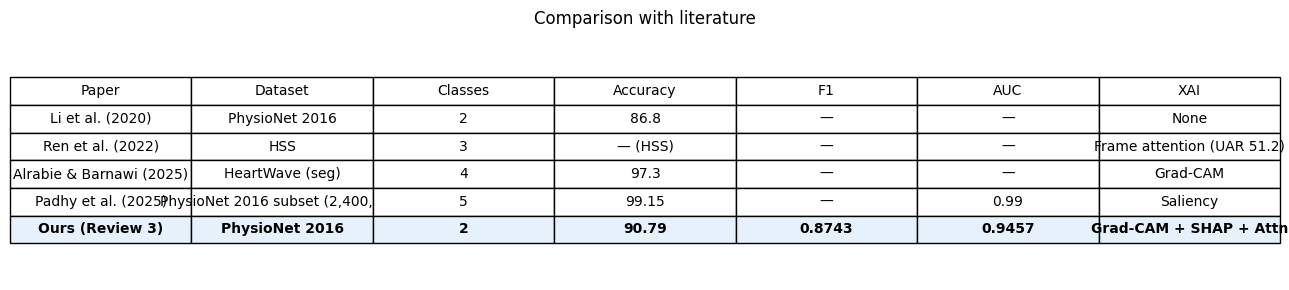

  Saved: /content/drive/MyDrive/CSE/College/RMS/Review 3/output/comparison_table.png


,Paper,Dataset,Classes,Accuracy,F1,AUC,XAI
0,Li et al. (2020),PhysioNet 2016,2,86.8,—,—,None
1,Ren et al. (2022),HSS,3,— (HSS),—,—,Frame attention (UAR 51.2)
2,Alrabie & Barnawi (2025),HeartWave (seg),4,97.3,—,—,Grad-CAM
3,Padhy et al. (2025),"PhysioNet 2016 subset (2,400, bal)",5,99.15,—,0.99,Saliency
4,Ours (Review 3),PhysioNet 2016,2,90.79,0.8743,0.9457,Grad-CAM + SHAP + Attn


In [18]:
build_comparison_table(metrics,
                       save_path=paths.output_dir / 'comparison_table.png')

## Summary

Artifacts produced in `paths.output_dir`:
- `training_history.png` — loss / accuracy / F1 / LR curves
- `confusion_matrix.png` — counts + row-normalised
- `roc_pr_curves.png`    — ROC and PR curves
- `test_predictions.csv` — per-recording probabilities and predictions
- `test_metrics.json`    — scalar metrics
- `gradcam_overlays.png`, `attention_overlays.png`, `shap_*.png` — XAI plots
- `comparison_table.png` — versus literature
- `checkpoints/best_model.pth` + `history.json` — model + training trace
